In [1]:
import os
import copy
import glob
import random
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from torchvision import transforms
import matplotlib.pyplot as plt
import cv2
import imageio
from tqdm import tqdm
os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "1"
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")


'expandable_segments:True'

In [2]:


# # Import your local modules
# # Ensure conditional_unet_depth.py and diffusion.py are in the same folder
# from conditional_unet_depth import ConditionalUNetDepth
# from diffusion import GaussianDiffusion, DiffusionConfig

# # --- Configuration ---
# CONFIG = {
#     "img_size": 128,        # Resize all images to this (e.g., 128 or 256)
#     "batch_size": 16,       # Adjust based on VRAM (8GB should handle 16-32 at 128x128)
#     "lr": 1e-4,
#     "epochs": 25,
#     "timesteps": 1000,
#     "device": "cuda" if torch.cuda.is_available() else "cpu",
#     # Paths are relative to the term_project folder
#     "synthetic_root": "../dataset/cleargrasp-dataset-train-resized",
#     # Use both d415_dataset and d435_dataset under real-val
#     "real_val_root": "../dataset/real-val",
#     "ema_decay": 0.995,  # How slow the EMA model updates
#     "loss_type": "l2"  # l1 sharper or l2 standard
# }

# print(f"Running on device: {CONFIG['device']}")


In [3]:
# Config: paths and hyperparameters
import os
from dataclasses import dataclass

# Set your dataset root that contains: rgb/, depth/, mask/ (256x256 each)
DATASET_ROOT = "/home/cago/MMI_714_generative_models/term_project/dataset/cleargrasp-dataset-train-resized/"
RGB_DIR = "rgb-imgs"
DEPTH_DIR = "depth-imgs-rectified"
MASK_DIR = "segmentation-masks"

# Depth range in meters for normalization to [-1,1]
DEPTH_MINMAX = (0.0, 5.0)

# Noise parameters (normalized depth space [-1,1])
SIGMA_MASK = 0.08     # heavy noise on transparent regions
SIGMA_GLOBAL = 0.01   # light noise everywhere

# Training
BATCH_SIZE = 8  # lowered to fit 8GB VRAM at 128x128
LR = 1e-4
EPOCHS = 1            # increase for real training
TIMESTEPS = 1000
NUM_WORKERS = 2
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.cudnn.benchmark = True if DEVICE == "cuda" else False


In [4]:
# Imports and dataset/dataloaders
import torch
from torch.utils.data import DataLoader
from diffusion import GaussianDiffusion, DiffusionConfig
from conditional_unet_depth import ConditionalUNetDepth
from data_pipeline import DepthInpaintDataset, DepthDataConfig
from guidance_maps import GuidanceConfig

# Prepare datasets for optical and geometric branches
gcfg = GuidanceConfig()
IMG_SIZE = (128, 128)  # lowered resolution to fit 8GB VRAM
cfg_opt = DepthDataConfig(
    root=DATASET_ROOT, rgb_dir=RGB_DIR, depth_dir=DEPTH_DIR, mask_dir=MASK_DIR,
    size=IMG_SIZE, depth_minmax=DEPTH_MINMAX,
    sigma_mask=SIGMA_MASK, sigma_global=SIGMA_GLOBAL,
    branch="optical", include_guidance=True,
 )
cfg_geo = DepthDataConfig(
    root=DATASET_ROOT, rgb_dir=RGB_DIR, depth_dir=DEPTH_DIR, mask_dir=MASK_DIR,
    size=IMG_SIZE, depth_minmax=DEPTH_MINMAX,
    sigma_mask=SIGMA_MASK, sigma_global=SIGMA_GLOBAL,
    branch="geometric", include_guidance=True,
 )

ds_opt = DepthInpaintDataset(cfg_opt, gcfg)
ds_geo = DepthInpaintDataset(cfg_geo, gcfg)

dl_opt = DataLoader(ds_opt, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
dl_geo = DataLoader(ds_geo, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)


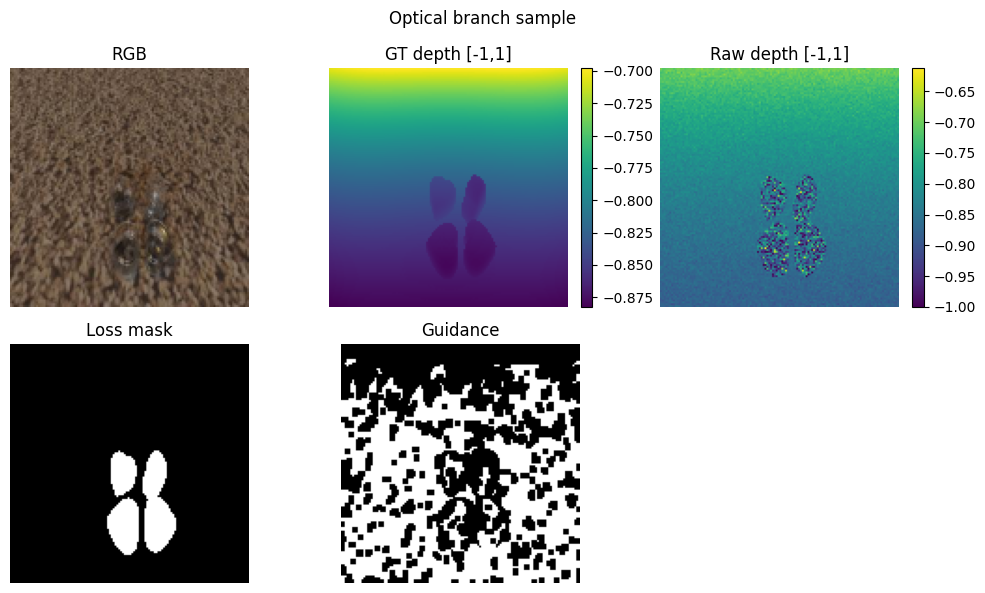

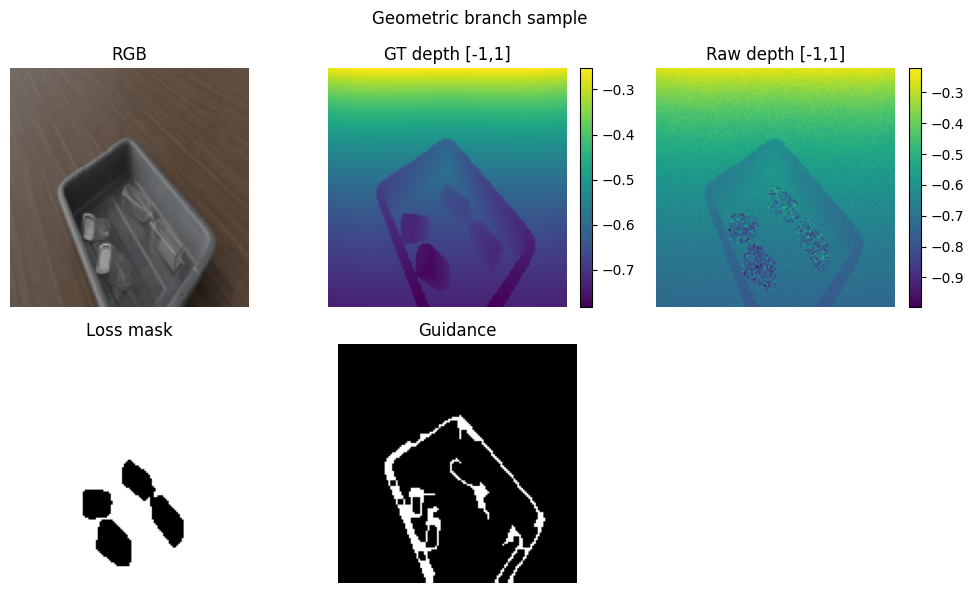

In [5]:
# Visualize a sample from each branch
import matplotlib.pyplot as plt
import numpy as np
import cv2

def viz_sample(batch, title_prefix=""):
    depth = batch["pixel_values"][0].cpu().numpy()[0]  # [-1,1]
    cond = batch["conditioning"][0].cpu().numpy()
    loss_mask = batch["loss_mask"][0].cpu().numpy()[0]
    # cond layout: [RGB(3), raw(1), guide(1)]
    rgb = cond[:3]
    raw = cond[3]
    guide = cond[4]
    rgb_viz = (np.clip(rgb.transpose(1,2,0), 0, 1) * 255).astype(np.uint8)
    rgb_viz = cv2.cvtColor(rgb_viz, cv2.COLOR_RGB2BGR)
    plt.figure(figsize=(10,6))
    plt.suptitle(title_prefix)
    plt.subplot(2,3,1); plt.title("RGB"); plt.imshow(cv2.cvtColor(rgb_viz, cv2.COLOR_BGR2RGB)); plt.axis('off')
    plt.subplot(2,3,2); plt.title("GT depth [-1,1]"); plt.imshow(depth, cmap='viridis'); plt.colorbar(fraction=0.046); plt.axis('off')
    plt.subplot(2,3,3); plt.title("Raw depth [-1,1]"); plt.imshow(raw, cmap='viridis'); plt.colorbar(fraction=0.046); plt.axis('off')
    plt.subplot(2,3,4); plt.title("Loss mask"); plt.imshow(loss_mask, cmap='gray'); plt.axis('off')
    plt.subplot(2,3,5); plt.title("Guidance"); plt.imshow(guide, cmap='gray'); plt.axis('off')
    plt.tight_layout(); plt.show()

opt_batch = next(iter(dl_opt))
geo_batch = next(iter(dl_geo))
viz_sample(opt_batch, title_prefix="Optical branch sample")
viz_sample(geo_batch, title_prefix="Geometric branch sample")

In [6]:
# Training utility for a branch
def train_branch(branch_name: str, dataloader, save_path: str):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = ConditionalUNetDepth(cond_channels=5).to(device)
    diffusion = GaussianDiffusion(model=model, config=DiffusionConfig(timesteps=TIMESTEPS)).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))
    model.train()
    diffusion.train()
    step = 0
    for epoch in range(EPOCHS):
        epoch_bar = tqdm(dataloader, desc=f"[{branch_name}] Epoch {epoch+1}/{EPOCHS}", leave=False)
        for batch in epoch_bar:
            x0 = batch["pixel_values"].to(device, non_blocking=True)
            cond = batch["conditioning"].to(device, non_blocking=True)
            mask = batch.get("loss_mask", None)
            if mask is not None:
                mask = mask.to(device, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                loss = diffusion.p_losses({
                    "pixel_values": x0,
                    "conditioning": cond,
                    "loss_mask": mask,
                })
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt)
            scaler.update()
            if step % 50 == 0:
                print(f"[{branch_name}] step {step} loss {loss.item():.4f} on {device}")
            step += 1
    # save UNet weights (the diffusion wrapper has buffers, we'll save model only)
    torch.save(model.state_dict(), save_path)
    return model, diffusion

In [7]:
# Run short training for optical and geometric branches (saving checkpoints in CWD)
import os, torch
CHECKPOINT_DIR = os.getcwd()
opt_model_path = os.path.join(CHECKPOINT_DIR, "model_optical.pt")
geo_model_path = os.path.join(CHECKPOINT_DIR, "model_geometric.pt")
print(f"Saving checkpoints to: {CHECKPOINT_DIR}")
opt_model, opt_diff = train_branch("optical", dl_opt, opt_model_path)
del opt_model, opt_diff
torch.cuda.empty_cache()
geo_model, geo_diff = train_branch("geometric", dl_geo, geo_model_path)

Saving checkpoints to: /home/cago/MMI_714_generative_models/term_project/src


/tmp/ipykernel_90924/985883653.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))
[optical] Epoch 1/1:   0%|          | 0/22727 [00:00<?, ?it/s]/tmp/ipykernel_90924/985883653.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
/tmp/ipykernel_90924/985883653.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
[optical] Epoch 1/1:   0%|          | 1/22727 [00:37<237:47:36, 37.67s/it]

[optical] step 0 loss 1.2523 on cuda


[optical] Epoch 1/1:   0%|          | 52/22727 [00:46<1:08:41,  5.50it/s] 

[optical] step 50 loss 0.0351 on cuda


...

[optical] Epoch 1/1:   5%|▌         | 1152/22727 [04:07<1:05:27,  5.49it/s]

[optical] step 1150 loss 0.0078 on cuda


[optical] Epoch 1/1:   5%|▌         | 1202/22727 [04:17<1:05:07,  5.51it/s]

[optical] step 1200 loss 0.0031 on cuda


KeyboardInterrupt: 

In [ ]:
# Inference: generate and merge optical + geometric predictions (robust to missing checkpoints)
import os
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def denorm_depth(dnorm, dmin, dmax):
    return (dnorm + 1.0) / 2.0 * (dmax - dmin) + dmin

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define checkpoint paths (using current working directory since __file__ is undefined in notebooks)
CHECKPOINT_DIR = os.getcwd()
opt_model_path = os.path.join(CHECKPOINT_DIR, "model_optical.pt")
geo_model_path = os.path.join(CHECKPOINT_DIR, "model_geometric.pt")
print(f"Checkpoint dir: {CHECKPOINT_DIR}")
print(f"Opt path: {opt_model_path}")
print(f"Geo path: {geo_model_path}")

# Build models
opt_model = ConditionalUNetDepth(cond_channels=5).to(device)
geo_model = ConditionalUNetDepth(cond_channels=5).to(device)

# Load if present, else keep random weights
if os.path.isfile(opt_model_path):
    print(f"Loading optical checkpoint: {opt_model_path}")
    opt_model.load_state_dict(torch.load(opt_model_path, map_location=device))
else:
    print(f"[WARN] Optical checkpoint not found at {opt_model_path}; using randomly initialized weights.")

if os.path.isfile(geo_model_path):
    print(f"Loading geometric checkpoint: {geo_model_path}")
    geo_model.load_state_dict(torch.load(geo_model_path, map_location=device))
else:
    print(f"[WARN] Geometric checkpoint not found at {geo_model_path}; using randomly initialized weights.")

opt_diff = GaussianDiffusion(model=opt_model, config=DiffusionConfig(timesteps=TIMESTEPS)).to(device)
geo_diff = GaussianDiffusion(model=geo_model, config=DiffusionConfig(timesteps=TIMESTEPS)).to(device)

opt_model.eval(); geo_model.eval()

with torch.no_grad():
    batch_opt = next(iter(dl_opt))
    batch_geo = next(iter(dl_geo))
    cond_opt = batch_opt["conditioning"].to(device, non_blocking=True)
    cond_geo = batch_geo["conditioning"].to(device, non_blocking=True)
    mask_opt = batch_opt["loss_mask"].to(device, non_blocking=True)  # transparent region
    mask_geo = batch_geo["loss_mask"].to(device, non_blocking=True)  # background region (1 - transparent)

    b, _, h, w = cond_opt.shape
    pred_opt = opt_diff.sample(cond=cond_opt, shape=(b,1,h,w), device=device)  # [-1,1]
    pred_geo = geo_diff.sample(cond=cond_geo, shape=(b,1,h,w), device=device)  # [-1,1]

    # Merge using masks (make sure masks are 1xHxW)
    m_opt = mask_opt
    m_geo = mask_geo
    merged = pred_opt * m_opt + pred_geo * m_geo

    # Visualize first sample
    gt = batch_opt["pixel_values"][0].cpu().numpy()[0]
    merged_np = merged[0].cpu().numpy()[0]
    raw = batch_opt["conditioning"][0][3].cpu().numpy()  # raw depth [-1,1]

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1); plt.title("Raw depth [-1,1]"); plt.imshow(raw, cmap='viridis'); plt.colorbar(fraction=0.046); plt.axis('off')
    plt.subplot(1,3,2); plt.title("GT depth [-1,1]"); plt.imshow(gt, cmap='viridis'); plt.colorbar(fraction=0.046); plt.axis('off')
    plt.subplot(1,3,3); plt.title("Merged pred [-1,1]"); plt.imshow(merged_np, cmap='viridis'); plt.colorbar(fraction=0.046); plt.axis('off')
    plt.tight_layout(); plt.show()

In [ ]:
# --- EMA (Exponential Moving Average) Helper Class ---

class EMA:
    """Maintains a slowly updating copy of the model weights."""
    def __init__(self, model, beta=0.995):
        self.beta = beta
        self.ema_model = copy.deepcopy(model)
        self.ema_model.eval()
        # Freeze EMA parameters (they are updated manually)
        for param in self.ema_model.parameters():
            param.requires_grad = False

    def update(self, model):
        """Update EMA parameters: new_ema = beta * old_ema + (1-beta) * current"""
        with torch.no_grad():
            for current_params, ema_params in zip(model.parameters(), self.ema_model.parameters()):
                ema_params.data = self.beta * ema_params.data + (1 - self.beta) * current_params.data

    def __call__(self, *args, **kwargs):
        return self.ema_model(*args, **kwargs)


In [ ]:

# --- Dataset Class ---

class ClearGraspDataset(Dataset):
    def __init__(self, root_dir, split="synthetic", img_size=128, max_depth=3.0):
        """
        Args:
            root_dir: Path to dataset folder.
            split: "synthetic" (training) or "real" (validation/test).
            img_size: Target size for resizing (square).
            max_depth: Maximum depth value (in meters) for normalization.
                       ClearGrasp usually clips around 3m-10m. 3.0m is a safe focus for manipulation.
        """
        self.root_dir = root_dir
        self.split = split
        self.img_size = img_size
        self.max_depth = max_depth

        self.samples = []

        if self.split == "synthetic":
            # Synthetic structure: Class/depth-imgs-rectified/*.exr
            # We need to find matching RGB and Mask files.
            # Assumes structure: class_name/depth-imgs-rectified/000.exr
            #                    class_name/rgb-imgs/000.jpg
            #                    class_name/segmentation-masks/000.png (or similar)

            # Walk through all class folders
            for class_folder in glob.glob(os.path.join(root_dir, "*")):
                if not os.path.isdir(class_folder): continue

                depth_folder = os.path.join(class_folder, "depth-imgs-rectified")
                rgb_folder = os.path.join(class_folder, "rgb-imgs")
                # Note: Check the exact name of your mask folder in the synthetic dataset!
                # Often it is 'segmentation-masks' or similar.
                mask_folder = os.path.join(class_folder, "segmentation-masks")

                if not os.path.exists(depth_folder): continue

                depth_files = sorted(glob.glob(os.path.join(depth_folder, "*.exr")))

                for df in depth_files:
                    basename = os.path.basename(df).split("-")[0] # e.g. "000000000"

                    # Construct paths for RGB and Mask
                    # Adjust extensions/naming patterns based on your actual file listing!
                    rgb_path = os.path.join(rgb_folder, f"{basename}-rgb.jpg")
                    mask_path = os.path.join(mask_folder, f"{basename}-segmentation-mask.png")

                    if os.path.exists(rgb_path) and os.path.exists(mask_path):
                        self.samples.append({
                            "depth": df,
                            "rgb": rgb_path,
                            "mask": mask_path
                        })

        elif self.split == "real":
            # Real Val/Test structure (flat folder):
            # 000-opaque-depth-img.exr (Target)
            # 000-transparent-depth-img.exr (Input Bad Depth)
            # 000-transparent-rgb-img.jpg (Input RGB)

            # We iterate over opaque depth (ground truth targets)
            target_files = sorted(glob.glob(os.path.join(root_dir, "**", "*-opaque-depth-img.exr"), recursive=True))

            for tf in target_files:
                # e.g. .../000000000-opaque-depth-img.exr
                prefix = tf.split("-opaque")[0] # .../000000000

                input_depth_path = f"{prefix}-transparent-depth-img.exr"
                input_rgb_path = f"{prefix}-transparent-rgb-img.jpg"

                if os.path.exists(input_depth_path) and os.path.exists(input_rgb_path):
                    self.samples.append({
                        "target_depth": tf,
                        "input_depth": input_depth_path,
                        "rgb": input_rgb_path
                    })

        print(f"Found {len(self.samples)} samples for split: {split}")

    def load_exr(self, path):
        # Load EXR file using OpenCV
        img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
        if img is None:
            raise RuntimeError(f"Failed to load EXR: {path}")
        # Handle potential multi-channel EXR (take first channel if 3)
        if len(img.shape) == 3:
            img = img[:, :, 0]
        img = img.astype(np.float32)
        # Replace NaN / Inf with 0 (background)
        img = np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)
        return img

    def process_image(self, img, image_type="rgb"):
        """
        image_type: 'rgb', 'depth', or 'mask'
        """
        # 1. Center Crop
        h, w = img.shape[:2]
        min_dim = min(h, w)
        top, left = (h - min_dim) // 2, (w - min_dim) // 2
        img = img[top:top+min_dim, left:left+min_dim]

        # 2. Resize
        interp = cv2.INTER_LINEAR if image_type == "rgb" else cv2.INTER_NEAREST
        img = cv2.resize(img, (self.img_size, self.img_size), interpolation=interp)

        # 3. To Tensor & Normalize
        if image_type == "rgb":
            # RGB: [0, 255] -> [-1, 1]
            img = torch.from_numpy(img).permute(2, 0, 1).float()
            img = (img / 127.5) - 1.0

        elif image_type == "mask":
            # Mask: [0, 255] -> [0, 1]
            img = torch.from_numpy(img).unsqueeze(0).float()
            img = img / 255.0  # Masks are always 0-255

        elif image_type == "depth":
            # Depth: [0, max_depth] -> [-1, 1]
            img = torch.from_numpy(img).unsqueeze(0).float()
            # CRITICAL FIX: Do NOT check img.max() here. Always normalize depth.
            img = torch.clamp(img, 0, self.max_depth)
            img = img / self.max_depth # Now [0, 1]
            img = (img * 2.0) - 1.0    # Now [-1, 1]

        return img

    def apply_realistic_corruption(self, depth, mask):
        """
        Apply realistic sensor-like corruption to depth inside transparent-object regions.

        depth: (1, H, W) normalized tensor in [-1, 1]
        mask : (1, H, W) tensor in [0, 1], where > 0 indicates object.
        """
        corrupted = depth.clone()

        # Object region (transparent object)
        object_indices = (mask > 0.0)

        if not object_indices.any():
            return corrupted

        # 1. Dropout: some pixels become completely "missing" (-1.0 after normalization)
        dropout_prob = 0.6
        dropout_mask = (torch.rand_like(depth) < dropout_prob) & object_indices
        corrupted[dropout_mask] = -1.0

        # 2. Noise: remaining object pixels get strong depth noise
        noise_indices = object_indices & (~dropout_mask)

        if noise_indices.any():
            # Strong Gaussian noise in [-1, 1] space
            noise = torch.randn_like(depth) * 0.5
            corrupted[noise_indices] = corrupted[noise_indices] + noise[noise_indices]
            # Clip back to valid range
            corrupted = torch.clamp(corrupted, -1.0, 1.0)

        return corrupted

    def __getitem__(self, idx):
        sample = self.samples[idx]

        # RGB
        rgb = cv2.imread(sample["rgb"])
        rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)
        rgb_tensor = self.process_image(rgb, image_type="rgb")

        if self.split == "synthetic":
            target_depth_raw = self.load_exr(sample["depth"])
            mask = cv2.imread(sample["mask"], cv2.IMREAD_GRAYSCALE)

            # Ensure mask matches depth size before processing
            if mask.shape != target_depth_raw.shape:
                mask = cv2.resize(mask, (target_depth_raw.shape[1], target_depth_raw.shape[0]), interpolation=cv2.INTER_NEAREST)

            # Explicitly specify types now!
            target_depth_tensor = self.process_image(target_depth_raw, image_type="depth")
            mask_tensor = self.process_image(mask, image_type="mask")

            input_depth_tensor = self.apply_realistic_corruption(target_depth_tensor, mask_tensor)

        else:
            # Real data
            target_depth_raw = self.load_exr(sample["target_depth"])
            input_depth_raw = self.load_exr(sample["input_depth"])

            target_depth_tensor = self.process_image(target_depth_raw, image_type="depth")
            input_depth_tensor = self.process_image(input_depth_raw, image_type="depth")

        conditioning = torch.cat([rgb_tensor, input_depth_tensor], dim=0)

        return {
            "pixel_values": target_depth_tensor,
            "conditioning": conditioning
        }

    def __len__(self):
        return len(self.samples)